<a href="https://colab.research.google.com/github/habiba-cap/DecodeLabs--internship/blob/main/main_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('/content/retail_store_sales.csv')
print("--- Dataset Information ---")
df.info()
print(f"\nTotal Transactions: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")
df.head()

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB

Total Transactions: 12575
Total Features: 11


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64


In [ ]:
df['Discount Applied'] = df['Discount Applied'].fillna(False)
df.dropna(subset=['Price Per Unit', 'Quantity', 'Total Spent'], inplace=True)

/tmp/ipykernel_3023/3960499772.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Discount Applied'] = df['Discount Applied'].fillna(False)


In [ ]:
import numpy as np
# If Price is missing, fill it with the median price of its Category
df['Price Per Unit'] = df.groupby('Category')['Price Per Unit'].transform(lambda x: x.fillna(x.median()))
# If Total Spent is missing (Price * Quantity)
df['Total Spent'] = df['Total Spent'].fillna(df['Price Per Unit'] * df['Quantity'])
# Capping outliers to the 99th percentile
upper_limit = df['Total Spent'].quantile(0.99)
df['Total Spent'] = np.where(df['Total Spent'] > upper_limit, upper_limit, df['Total Spent'])

Cleaning and Feature Engineering complete.


In [ ]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Month'] = df['Transaction Date'].dt.month_name()
df['Day_of_Week'] = df['Transaction Date'].dt.day_name()

In [ ]:
df = df.drop_duplicates()
print(f"\nCleaned dataset size: {df.shape}")


Cleaned dataset size: (11362, 11)


In [ ]:
print(df[['Price Per Unit', 'Quantity', 'Total Spent']].describe())

       Price Per Unit      Quantity   Total Spent
count    11362.000000  11971.000000  11971.000000
mean        23.356847      5.536380    129.652577
std         10.736030      2.857883     94.750697
min          5.000000      1.000000      5.000000
25%         14.000000      3.000000     51.000000
50%         23.000000      6.000000    108.500000
75%         33.500000      8.000000    192.000000
max         41.000000     10.000000    410.000000


In [ ]:
category_revenue = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)
print("\n--- Revenue per Category ---")
print(category_revenue)


--- Revenue per Category ---
Category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: Total Spent, dtype: float64


In [ ]:
print("\n--- Revenue per Category ---")

print(category_revenue)

Q1 = df['Total Spent'].quantile(0.25)

Q3 = df['Total Spent'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[df['Total Spent'] > (Q3 + 1.5 * IQR)]

print(f"\nTotal High-Value Outliers Identified: {len(outliers)}")

discount_impact = df.groupby('Discount Applied')['Quantity'].mean()

print("\n--- Average Quantity Sold (With vs Without Discount) ---")

print(discount_impact)




Total High-Value Outliers Identified: 60


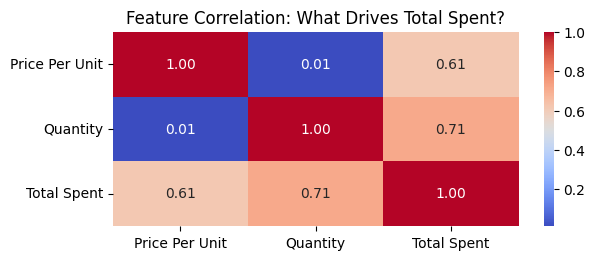

In [ ]:
# Shows which factors actually move together
plt.subplot(2, 1, 2)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation: What Drives Total Spent?')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3023/3084506245.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rev = df.resample('M', on='Transaction Date')['Total Spent'].sum()


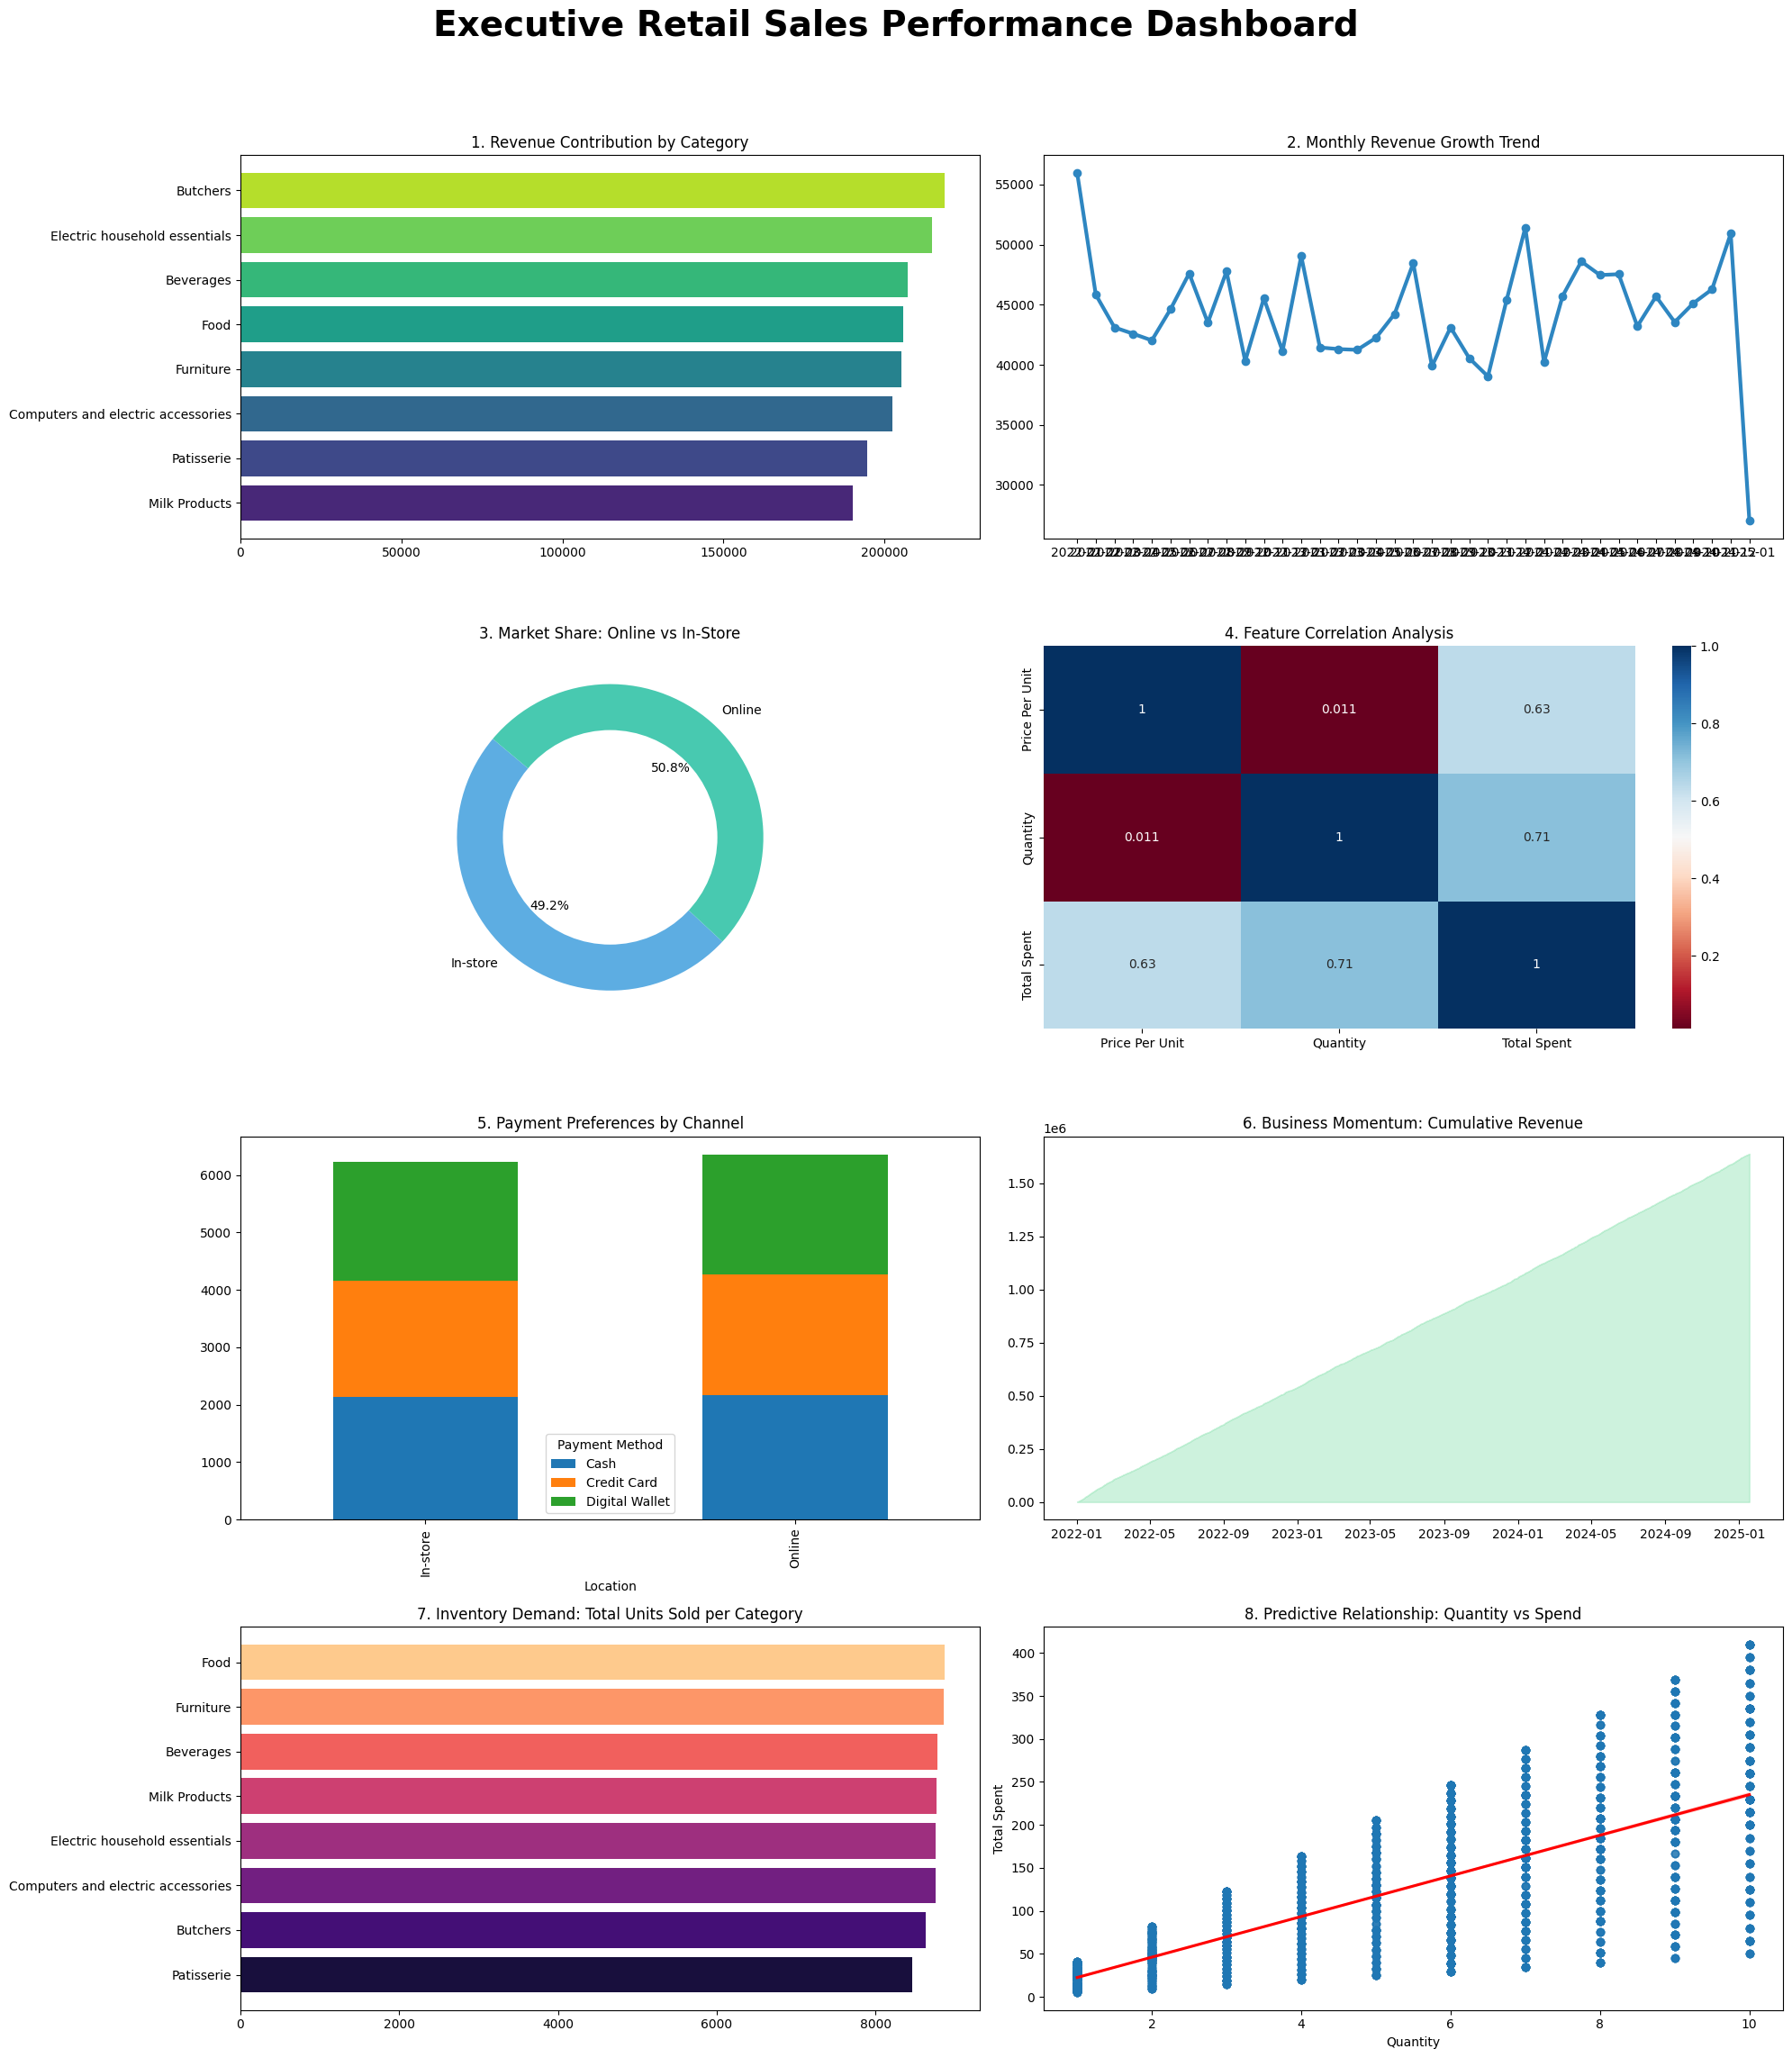

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('retail_store_sales.csv')
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])
df['Price Per Unit'] = df.groupby('Category')['Price Per Unit'].transform(lambda x: x.fillna(x.median()))
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Total Spent'] = df['Price Per Unit'] * df['Quantity']
fig, axes = plt.subplots(4, 2, figsize=(20, 24))
fig.suptitle('Executive Retail Sales Performance Dashboard', fontsize=28, fontweight='bold', y=0.98)

# 1. Revenue by Category
cat_revenue = df.groupby('Category')['Total Spent'].sum().sort_values()
axes[0, 0].barh(cat_revenue.index, cat_revenue.values, color=sns.color_palette("viridis", len(cat_revenue)))
axes[0, 0].set_title('1. Revenue Contribution by Category')

# 2. Monthly Revenue Trend
monthly_rev = df.resample('M', on='Transaction Date')['Total Spent'].sum()
axes[0, 1].plot(monthly_rev.index.strftime('%Y-%m'), monthly_rev.values, marker='o', linewidth=3, color='#2E86C1')
axes[0, 1].set_title('2. Monthly Revenue Growth Trend')

# 3. Online vs In-Store Share
loc_revenue = df.groupby('Location')['Total Spent'].sum()
axes[1, 0].pie(loc_revenue, labels=loc_revenue.index, autopct='%1.1f%%', startangle=140, colors=['#5DADE2', '#48C9B0'])
axes[1, 0].add_artist(plt.Circle((0,0), 0.70, fc='white'))
axes[1, 0].set_title('3. Market Share: Online vs In-Store')

# 4. Correlation Heatmap
sns.heatmap(df[['Price Per Unit', 'Quantity', 'Total Spent']].corr(), annot=True, cmap='RdBu', ax=axes[1, 1])
axes[1, 1].set_title('4. Feature Correlation Analysis')

# 5. Payment Methods by Location
pd.crosstab(df['Location'], df['Payment Method']).plot(kind='bar', stacked=True, ax=axes[2, 0])
axes[2, 0].set_title('5. Payment Preferences by Channel')

# 6. Cumulative Growth
df_sorted = df.sort_values('Transaction Date')
axes[2, 1].fill_between(df_sorted['Transaction Date'], df_sorted['Total Spent'].cumsum(), color="#82E0AA", alpha=0.4)
axes[2, 1].set_title('6. Business Momentum: Cumulative Revenue')

# 7. Inventory Demand
cat_qty = df.groupby('Category')['Quantity'].sum().sort_values()
axes[3, 0].barh(cat_qty.index, cat_qty.values, color=sns.color_palette("magma", len(cat_qty)))
axes[3, 0].set_title('7. Inventory Demand: Total Units Sold per Category')

# 8. Regression (Quantity vs Spend)
sns.regplot(data=df, x='Quantity', y='Total Spent', scatter_kws={'alpha':0.1}, line_kws={'color':'red'}, ax=axes[3, 1])
axes[3, 1].set_title('8. Predictive Relationship: Quantity vs Spend')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('retail_sales_dashboard.png', dpi=300)
plt.show()

/tmp/ipykernel_3023/1294798122.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.heatmap(df.groupby(['Month', 'Category'])['Total Spent'].sum().unstack(), cmap='YlOrRd', ax=axes[1,0])


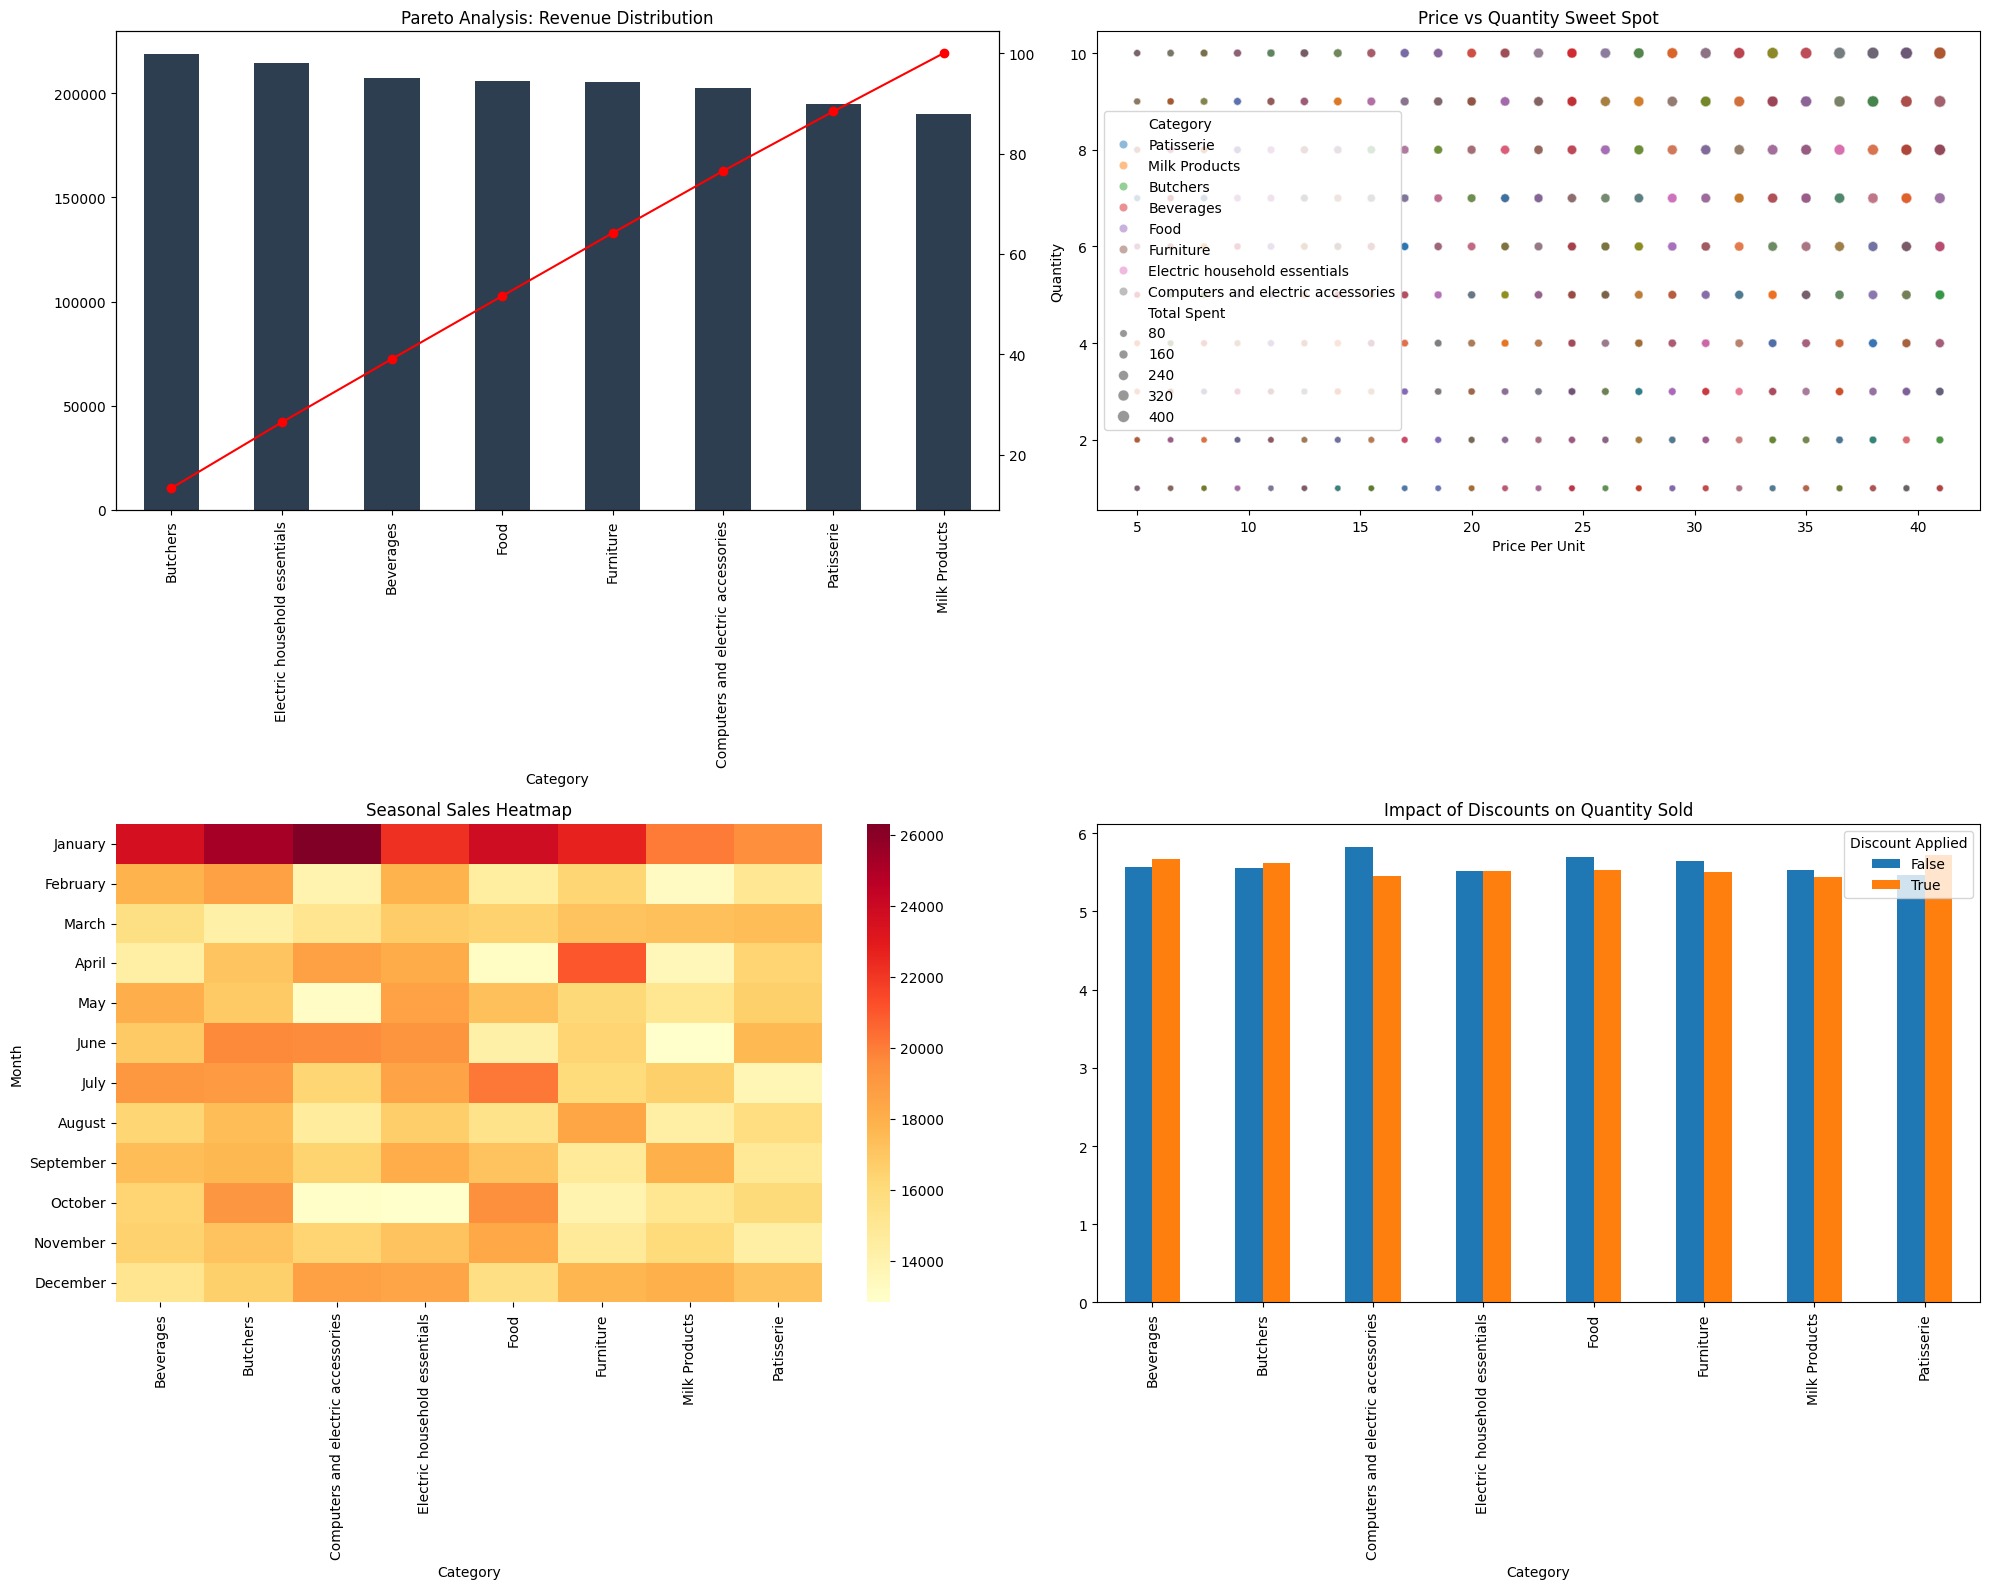

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df['Month'] = pd.Categorical(df['Transaction Date'].dt.month_name(),
                             categories=['January', 'February', 'March', 'April', 'May', 'June',
                                         'July', 'August', 'September', 'October', 'November', 'December'],
                             ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Pareto
cat_rev = df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False)
cat_rev.plot(kind='bar', ax=axes[0,0], color='#2C3E50')
ax2 = axes[0,0].twinx()
(cat_rev.cumsum()/cat_rev.sum()*100).plot(ax=ax2, color='red', marker='o')
axes[0,0].set_title('Pareto Analysis: Revenue Distribution')

# 2. Bubble Chart
sns.scatterplot(data=df, x='Price Per Unit', y='Quantity', size='Total Spent', hue='Category', ax=axes[0,1], alpha=0.5)
axes[0,1].set_title('Price vs Quantity Sweet Spot')

# 3. Heatmap
sns.heatmap(df.groupby(['Month', 'Category'])['Total Spent'].sum().unstack(), cmap='YlOrRd', ax=axes[1,0])
axes[1,0].set_title('Seasonal Sales Heatmap')

# 4. Discount Impact
df.groupby(['Category', 'Discount Applied'])['Quantity'].mean().unstack().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Impact of Discounts on Quantity Sold')
plt.tight_layout()
plt.show()

In [31]:
import os
folders = ['data', 'notebooks', 'models', 'src']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

In [30]:
with open(".gitignore", "w") as f:
    f.write("data/\nvenv/\n.ipynb_checkpoints/\n__pycache__/")

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
